In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

# 1. 데이터 로드
input_path = '../data/processed/smart_meter_data.csv'
df = pd.read_csv(input_path)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

print(f"📊 원본 데이터 로드 완료: {len(df)}건")

# ---------------------------------------------------------
# STEP 1. EDA (탐색적 데이터 분석 - 확인 단계)
# ---------------------------------------------------------
print("\n🔍 [STEP 1] 데이터 무결성 확인 중...")
for col in ['Flow_Instant', 'Pressure']:
    neg_count = len(df[df[col] < 0])
    neg_ratio = (neg_count / len(df)) * 100
    print(f"🚩 {col} 음수 데이터: {neg_count}건 ({neg_ratio:.4f}%)")


📊 원본 데이터 로드 완료: 36864건

🔍 [STEP 1] 데이터 무결성 확인 중...
🚩 Flow_Instant 음수 데이터: 13000건 (35.2648%)
🚩 Pressure 음수 데이터: 0건 (0.0000%)


🔍 음수 데이터 상세 분석
count    13000.000000
mean       -47.293228
std         28.497369
min       -179.930000
25%        -66.210000
50%        -43.180000
75%        -24.470000
max         -2.870000
Name: Flow_Instant, dtype: float64


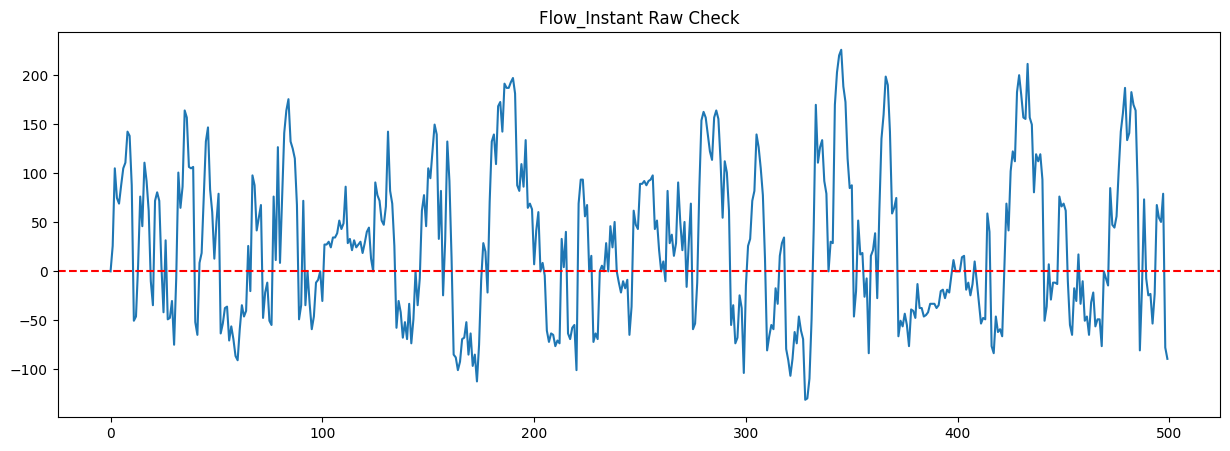

In [5]:

# 음수 데이터들이 대략 어떤 값들인지 확인
print("🔍 음수 데이터 상세 분석")
print(df[df['Flow_Instant'] < 0]['Flow_Instant'].describe())

# 시각화로 패턴 확인 (처음 500개만)
plt.figure(figsize=(15, 5))
plt.plot(df['Flow_Instant'][:500])
plt.axhline(0, color='red', linestyle='--')
plt.title("Flow_Instant Raw Check")
plt.show()


In [ ]:
# [STEP 2] 데이터 복원 및 정제
print("\n🔄 [STEP 2] 음수 데이터 복원 및 정제 중...")

# 1. 음수를 양수로 반전 (부호 오류 해결)
df['Flow_Instant_Abs'] = df['Flow_Instant'].abs()

# 2. 복원 후의 통계 확인 (EDA)
q99_flow = df['Flow_Instant_Abs'].quantile(0.99)
print(f"✅ 복원 후 유량 평균: {df['Flow_Instant_Abs'].mean():.2f}")
print(f"✅ 유량 상위 1% 임계치: {q99_flow:.2f}")

# 3. 이상치만 클리핑 (이제 lower=0은 의미가 없으므로 상한선만 조절)
df['Flow_Instant'] = df['Flow_Instant_Abs'].clip(upper=q99_flow)
df['Pressure'] = df['Pressure'].clip(lower=0) # 수압은 음수가 없었으니 그대로

print("✨ 음수 부호 반전 및 이상치 억제 완료")



🔄 [STEP 2] 음수 데이터 복원 및 정제 중...
✅ 복원 후 유량 평균: 59.61
✅ 유량 상위 1% 임계치: 192.89
✨ 음수 부호 반전 및 이상치 억제 완료


In [8]:
# ---------------------------------------------------------
# STEP 3. Resampling (해상도 조정 - 30분 단위)
# ---------------------------------------------------------
# 10분 단위는 너무 촘촘해서 7일치(미래)를 내다보기 힘듭니다. 
# 30분 단위 평균으로 뭉쳐서 '거시적인 흐름'을 만듭니다.
df_resampled = df.set_index('Timestamp').resample('30T').mean()

# 리샘플링 과정에서 생기는 빈틈(결측치)은 앞뒤 값을 이어주는 '선형 보간'으로 채웁니다.
df_resampled = df_resampled.interpolate(method='linear')
print(f"✅ 리샘플링 완료: {len(df_resampled)}개 시점 생성")

✅ 리샘플링 완료: 12289개 시점 생성


C:\Users\USER\AppData\Local\Temp\ipykernel_17688\1060745915.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df.set_index('Timestamp').resample('30T').mean()


In [10]:
# ---------------------------------------------------------
# STEP 4. Scaling (수치 표준화 - MinMaxScaler)
# ---------------------------------------------------------
# 유량(0~200)과 수압(0~10)은 단위 체급이 다릅니다. 
# AI가 편견 없이 공부하도록 둘 다 0~1 사이로 맞춥니다.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# 학습에 사용할 핵심 컬럼만 추출하여 변환
df_final = pd.DataFrame(
    scaler.fit_transform(df_resampled[['Flow_Instant', 'Pressure']]),
    columns=['Flow_Instant', 'Pressure'],
    index=df_resampled.index
)
print("✅ 스케일링 완료: 모든 데이터가 0~1 범위로 표준화됨")


✅ 스케일링 완료: 모든 데이터가 0~1 범위로 표준화됨


In [11]:

# ---------------------------------------------------------
# STEP 5. 최종 데이터 및 스케일러 저장
# ---------------------------------------------------------
import joblib
# 최종 결과물 저장
df_final.to_csv('../data/processed/smart_meter_final.csv')
# 나중에 예측값을 실제 리터(L)로 복원할 때 쓸 '기준표(스케일러)' 저장
joblib.dump(scaler, '../models/minmax_scaler.pkl')

print("✨ [전처리 종료] smart_meter_final.csv 생성 완료!")

✨ [전처리 종료] smart_meter_final.csv 생성 완료!
